# Clustering Analysis — Student Profiling (H3)

## Step 1: Select Behavioral Features for Clustering

In [1]:
import pandas as pd
import numpy as np
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv('../datasets/student_exam_features.csv')

# Use only behavioral features — no scores, no targets, no previous_gpa
cluster_features = ['study_hours_per_day', 'attendance_rate', 'sleep_hours',
                    'social_media_hours', 'assignment_completion_rate',
                    'online_courses_completed']
X_cluster = df[cluster_features].copy()
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_cluster)
print(f"Clustering features: {cluster_features}")
print(f"Shape: {X_scaled.shape}")

Clustering features: ['study_hours_per_day', 'attendance_rate', 'sleep_hours', 'social_media_hours', 'assignment_completion_rate', 'online_courses_completed']
Shape: (10000, 6)


## Step 2: Elbow Method and Silhouette Score

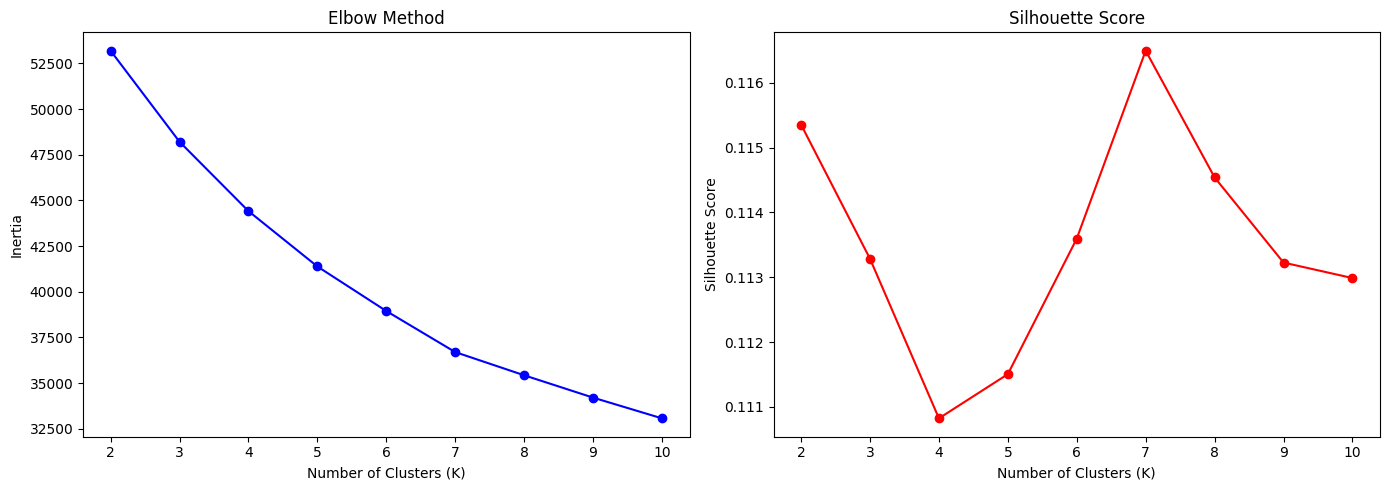

Silhouette scores:
  K=2: 0.1154
  K=3: 0.1133
  K=4: 0.1108
  K=5: 0.1115
  K=6: 0.1136
  K=7: 0.1165
  K=8: 0.1145
  K=9: 0.1132
  K=10: 0.1130


In [2]:
inertias = []
silhouettes = []
K_range = range(2, 11)
for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_scaled, km.labels_))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(K_range, inertias, 'bo-')
axes[0].set_xlabel('Number of Clusters (K)')
axes[0].set_ylabel('Inertia')
axes[0].set_title('Elbow Method')

axes[1].plot(K_range, silhouettes, 'ro-')
axes[1].set_xlabel('Number of Clusters (K)')
axes[1].set_ylabel('Silhouette Score')
axes[1].set_title('Silhouette Score')

plt.tight_layout()
plt.savefig('../deliverables/figures/14_elbow_silhouette.png', dpi=150, bbox_inches='tight')
plt.show()

print("Silhouette scores:")
for k, s in zip(K_range, silhouettes):
    print(f"  K={k}: {s:.4f}")

## Step 3: Fit Final K-Means Model

In [3]:
# K = 3. NOTE: silhouette is flat (~0.11) across all K=2..10 (see Step 2), indicating
# NO strong natural cluster structure. K=3 is therefore chosen on the basis of the
# elbow + interpretability (three actionable behavioral profiles), NOT because it
# maximizes silhouette (the numeric max is at K=7, only marginally higher than K=3).
# This is an exploratory segmentation, not evidence of well-separated clusters.
optimal_k = 3
km_final = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
df['cluster'] = km_final.fit_predict(X_scaled)

print(f"Optimal K: {optimal_k} (chosen for interpretability; silhouette flat ~0.11)")
print(f"\nCluster sizes:")
print(df['cluster'].value_counts().sort_index())

Optimal K: 3 (chosen for interpretability; silhouette flat ~0.11)

Cluster sizes:
cluster
0    4008
1    3274
2    2718
Name: count, dtype: int64


## Step 4: Profile Each Cluster

In [4]:
profile_cols = cluster_features + ['previous_gpa', 'final_exam_score', 'pass_fail_enc']
cluster_profiles = df.groupby('cluster')[profile_cols].mean().round(2)
print("Cluster Profiles:")
print(cluster_profiles)

Cluster Profiles:
         study_hours_per_day  attendance_rate  sleep_hours  \
cluster                                                      
0                       2.78            85.02         6.85   
1                       3.31            84.24         7.21   
2                       3.03            84.81         7.03   

         social_media_hours  assignment_completion_rate  \
cluster                                                   
0                      1.96                       88.08   
1                      3.25                       68.30   
2                      2.45                       80.30   

         online_courses_completed  previous_gpa  final_exam_score  \
cluster                                                             
0                            1.32          2.02             50.75   
1                            1.39          1.94             48.33   
2                            3.85          1.99             49.74   

         pass_fail_enc  
clus

## Step 5: PCA 2D Projection

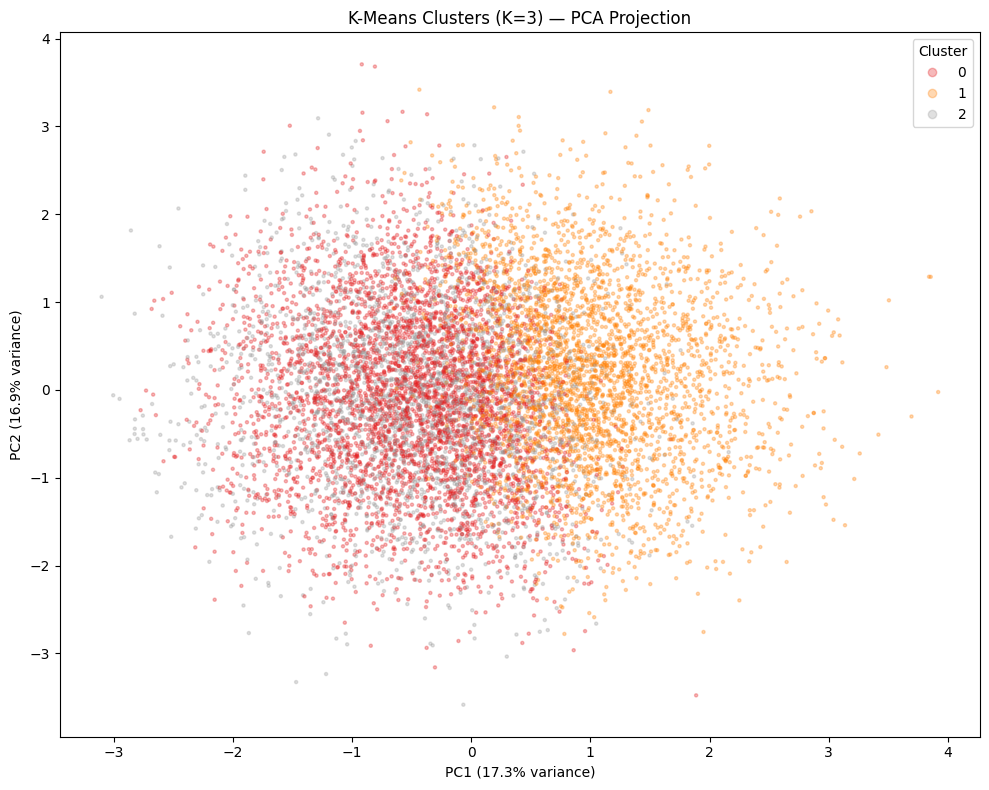

PCA explained variance: PC1=17.3%, PC2=16.9%


In [5]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(10, 8))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=df['cluster'], cmap='Set1', alpha=0.3, s=5)
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)')
plt.title(f'K-Means Clusters (K={optimal_k}) — PCA Projection')
plt.legend(*scatter.legend_elements(), title='Cluster')
plt.tight_layout()
plt.savefig('../deliverables/figures/15_cluster_pca.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"PCA explained variance: PC1={pca.explained_variance_ratio_[0]*100:.1f}%, PC2={pca.explained_variance_ratio_[1]*100:.1f}%")

## Step 6: Cluster Radar Chart

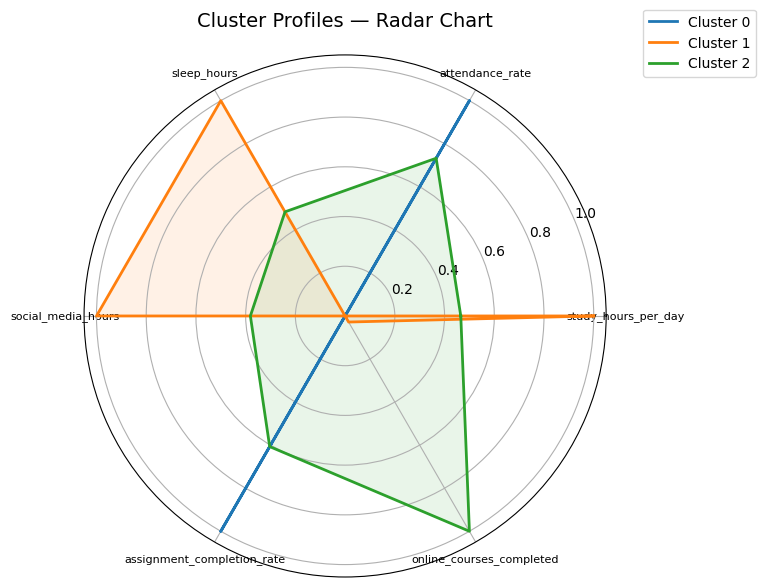

In [6]:
from math import pi

cluster_means = df.groupby('cluster')[cluster_features].mean()
cluster_means_norm = (cluster_means - cluster_means.min()) / (cluster_means.max() - cluster_means.min())

categories = cluster_features
N = len(categories)
angles = [n / float(N) * 2 * pi for n in range(N)]
angles += angles[:1]

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))
for cluster_id in range(optimal_k):
    values = cluster_means_norm.loc[cluster_id].tolist()
    values += values[:1]
    ax.plot(angles, values, linewidth=2, label=f'Cluster {cluster_id}')
    ax.fill(angles, values, alpha=0.1)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(categories, size=8)
ax.set_title('Cluster Profiles — Radar Chart', size=14, pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))
plt.tight_layout()
plt.savefig('../deliverables/figures/16_cluster_radar.png', dpi=150, bbox_inches='tight')
plt.show()

## Step 7: Save Clustered Dataset

In [7]:
df.to_csv('../datasets/student_exam_clustered.csv', index=False)
print(f"Clustered dataset saved: {df.shape}")

Clustered dataset saved: (10000, 36)


## Step 8: Cluster Interpretation and Comparison


Cluster 0 (n=4008):
  Study hours/day: 2.8
  Attendance rate: 85.0%
  Social media hrs: 2.0
  Sleep hours: 6.8
  Assignment rate: 88.1%
  Previous GPA: 2.02
  Final exam score: 50.8
  Pass rate: 51.0%

Cluster 1 (n=3274):
  Study hours/day: 3.3
  Attendance rate: 84.2%
  Social media hrs: 3.2
  Sleep hours: 7.2
  Assignment rate: 68.3%
  Previous GPA: 1.94
  Final exam score: 48.3
  Pass rate: 44.0%

Cluster 2 (n=2718):
  Study hours/day: 3.0
  Attendance rate: 84.8%
  Social media hrs: 2.5
  Sleep hours: 7.0
  Assignment rate: 80.3%
  Previous GPA: 1.99
  Final exam score: 49.7
  Pass rate: 50.0%


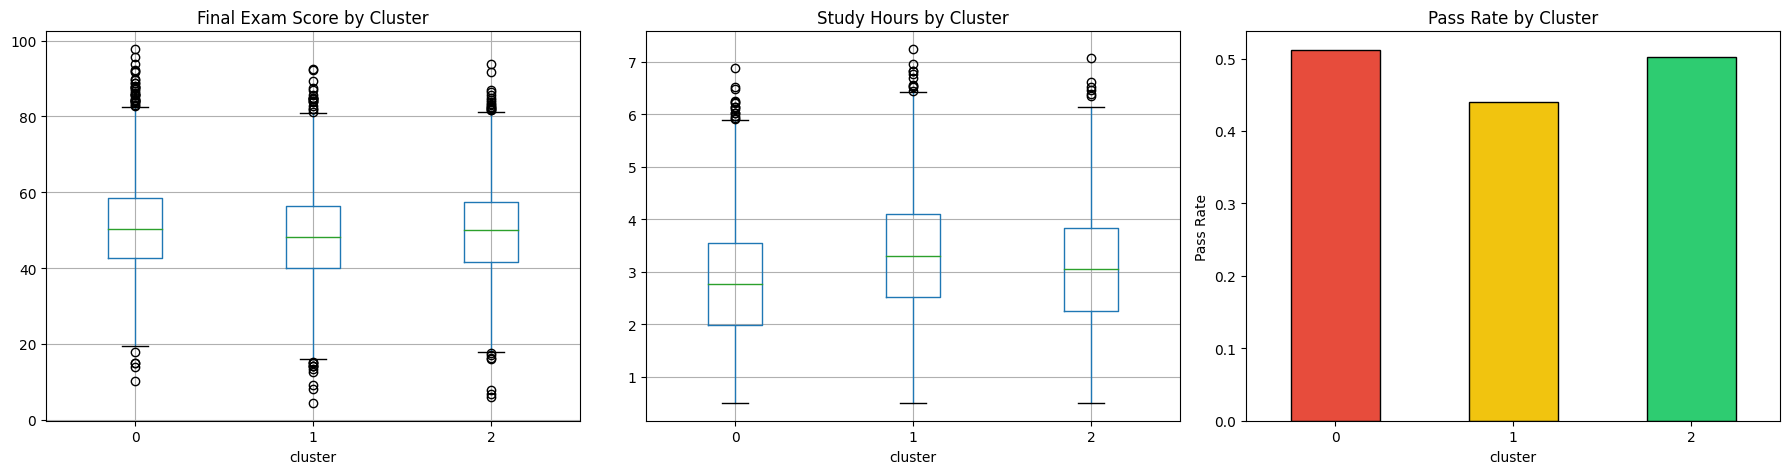

In [8]:
for cluster_id in range(optimal_k):
    profile = cluster_profiles.loc[cluster_id]
    n = df[df['cluster'] == cluster_id].shape[0]
    print(f"\nCluster {cluster_id} (n={n}):")
    print(f"  Study hours/day: {profile['study_hours_per_day']:.1f}")
    print(f"  Attendance rate: {profile['attendance_rate']:.1f}%")
    print(f"  Social media hrs: {profile['social_media_hours']:.1f}")
    print(f"  Sleep hours: {profile['sleep_hours']:.1f}")
    print(f"  Assignment rate: {profile['assignment_completion_rate']:.1f}%")
    print(f"  Previous GPA: {profile['previous_gpa']:.2f}")
    print(f"  Final exam score: {profile['final_exam_score']:.1f}")
    print(f"  Pass rate: {profile['pass_fail_enc']:.1%}")

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

df.boxplot(column='final_exam_score', by='cluster', ax=axes[0])
axes[0].set_title('Final Exam Score by Cluster')

df.boxplot(column='study_hours_per_day', by='cluster', ax=axes[1])
axes[1].set_title('Study Hours by Cluster')

pass_rates = df.groupby('cluster')['pass_fail_enc'].mean()
colors = ['#e74c3c', '#f1c40f', '#2ecc71'][:optimal_k]
pass_rates.plot(kind='bar', ax=axes[2], color=colors, edgecolor='black')
axes[2].set_title('Pass Rate by Cluster')
axes[2].set_ylabel('Pass Rate')
axes[2].tick_params(axis='x', rotation=0)

plt.suptitle('')
plt.tight_layout()
plt.savefig('../deliverables/figures/17_cluster_comparisons.png', dpi=150, bbox_inches='tight')
plt.show()

## Step 9: H3 Evaluation

In [9]:
from scipy import stats

print("=" * 60)
print("H3 Evaluation: Siswa dapat dikelompokkan ke cluster")
print("=" * 60)

for cluster_id in range(optimal_k):
    profile = cluster_profiles.loc[cluster_id]
    n = df[df['cluster'] == cluster_id].shape[0]
    print(f"\nCluster {cluster_id} (n={n}):")
    print(f"  final_exam_score: {profile['final_exam_score']:.1f}")
    print(f"  pass_rate: {profile['pass_fail_enc']:.1%}")

# --- Statistical tests across clusters (computed here, not hardcoded elsewhere) ---
groups = [df.loc[df['cluster'] == c, 'final_exam_score'].values for c in range(optimal_k)]
f_stat, p_anova = stats.f_oneway(*groups)
h_stat, p_kw = stats.kruskal(*groups)

# eta-squared (effect size) for the one-way ANOVA
grand = df['final_exam_score'].values; gm = grand.mean()
ss_between = sum(len(g) * (g.mean() - gm) ** 2 for g in groups)
ss_total = ((grand - gm) ** 2).sum()
eta2 = ss_between / ss_total

print(f"\nANOVA across clusters:          F={f_stat:.2f}, p={p_anova:.2e}, eta^2={eta2:.4f}")
print(f"Kruskal-Wallis across clusters: H={h_stat:.2f}, p={p_kw:.2e}")

# --- Practical-significance decision rule ---
# Thresholds: clusters are deemed PRACTICALLY distinct for intervention targeting only
# if the mean final_exam_score gap exceeds 5 points (on the ~4-98 scale) OR the pass-rate
# gap exceeds 10 percentage points. Rationale: with N=10,000 even a trivial gap is
# statistically significant (see eta^2 above), so practical thresholds — not p-values —
# must govern the H3 decision.
SCORE_GAP_THRESHOLD = 5.0       # points on final_exam_score
PASSRATE_GAP_THRESHOLD = 0.10   # 10 percentage points

score_range = cluster_profiles['final_exam_score'].max() - cluster_profiles['final_exam_score'].min()
pass_rate_range = cluster_profiles['pass_fail_enc'].max() - cluster_profiles['pass_fail_enc'].min()
print(f"\nScore range across clusters: {score_range:.1f} (threshold {SCORE_GAP_THRESHOLD})")
print(f"Pass rate range across clusters: {pass_rate_range:.1%} (threshold {PASSRATE_GAP_THRESHOLD:.0%})")

h3_result = "DITERIMA" if score_range > SCORE_GAP_THRESHOLD or pass_rate_range > PASSRATE_GAP_THRESHOLD else "DITOLAK"
print(f"\nH3 Status: {h3_result}")
print(f"(Catatan: perbedaan signifikan secara statistik (p<0.001) TETAPI eta^2={eta2:.4f} "
      f"-> effect size negligible; tidak bermakna praktis.)")
print(f"H3 — Siswa {'dapat' if h3_result == 'DITERIMA' else 'tidak dapat'} dikelompokkan ke cluster "
      f"dengan karakteristik dan kebutuhan intervensi yang berbeda secara PRAKTIS.")

H3 Evaluation: Siswa dapat dikelompokkan ke cluster

Cluster 0 (n=4008):
  final_exam_score: 50.8
  pass_rate: 51.0%

Cluster 1 (n=3274):
  final_exam_score: 48.3
  pass_rate: 44.0%

Cluster 2 (n=2718):
  final_exam_score: 49.7
  pass_rate: 50.0%

ANOVA across clusters:          F=36.01, p=2.62e-16, eta^2=0.0072
Kruskal-Wallis across clusters: H=61.22, p=5.09e-14

Score range across clusters: 2.4 (threshold 5.0)
Pass rate range across clusters: 7.0% (threshold 10%)

H3 Status: DITOLAK
(Catatan: perbedaan signifikan secara statistik (p<0.001) TETAPI eta^2=0.0072 -> effect size negligible; tidak bermakna praktis.)
H3 — Siswa tidak dapat dikelompokkan ke cluster dengan karakteristik dan kebutuhan intervensi yang berbeda secara PRAKTIS.
